# 🐬 swallow steering setpoint

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import trange

from bluer_options import string
from bluer_objects import file, objects, storage

from bluer_ugv.host import signature
from bluer_ugv.swallow.session.classical.setpoint.steering import generate_left_and_right
from bluer_ugv.tests.test_classical_setpoint_steering import test_cases
from bluer_ugv.logger import logger

logger.info(f"{'.'.join(signature())},\nbuilt on {string.pretty_date()}")

🐬  bluer_ugv-6.758.1.bluer_sbc-8.178.1.bluer_ai-12.257.1.bluer_objects-6.255.1.bluer_options-5.164.1.torch-2.2.2.Python 3.12.9.Darwin 23.6.0..Jupyter-Notebook,
built on 01 September 2025, 12:15:56


---

# test cases

In [2]:
for test_case in test_cases:
    test_case[2], test_case[3] = generate_left_and_right(
        speed=test_case[0], 
        steering=test_case[1],
    )

print(test_cases)

[[0, 0, 0, 0], [0, 50, -50, 50], [0, -50, 50, -50], [50, 0, 50, 50], [-50, 0, -50, -50], [50, 50, 0, 100], [50, -50, 100, 0], [-50, 50, -100, 0], [-50, -50, 0, -100]]


In [3]:
res = 200
object_name = "steering-setpoint-v1"

# calculation

In [4]:
speed_vals    = np.linspace(-100, 100, res)
steering_vals = np.linspace(-100, 100, res)
SPEED, STEER  = np.meshgrid(speed_vals, steering_vals)

# Vectorize your function to handle arrays
vfunc = np.vectorize(generate_left_and_right, otypes=[float, float])
LEFT, RIGHT = vfunc(SPEED, STEER)

# visualization

/var/folders/zt/yvc9hx9x3txdbl3ny6bfz6qr0000gn/T/ipykernel_20328/22263433.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


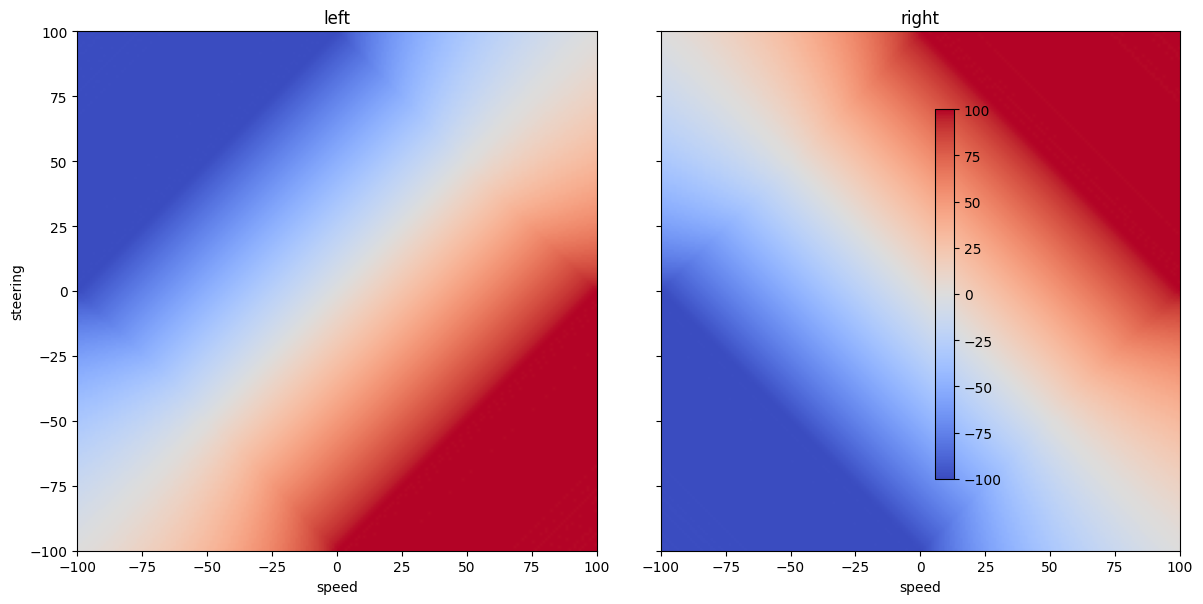

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

# left
im1 = ax1.imshow(
    LEFT,
    extent=[speed_vals.min(), speed_vals.max(), steering_vals.min(), steering_vals.max()],
    origin="lower",
    vmin=-100, vmax=100,
    cmap="coolwarm"   # diverging cmap is good for positive/negative contrast
)
ax1.set_title("left")
ax1.set_xlabel("speed")
ax1.set_ylabel("steering")

# right
im2 = ax2.imshow(
    RIGHT,
    extent=[speed_vals.min(), speed_vals.max(), steering_vals.min(), steering_vals.max()],
    origin="lower",
    vmin=-100, vmax=100,
    cmap="coolwarm"
)
ax2.set_title("right")
ax2.set_xlabel("speed")

# one shared colorbar
cbar = fig.colorbar(im1, ax=[ax1, ax2], shrink=0.8, pad=0.05)

plt.tight_layout()

assert file.save_fig(objects.path_of(
    object_name=object_name,
    filename="3d.png",
))

---

In [6]:
assert storage.upload(
    object_name=object_name,
    public=True,
)

  0%|          | 0/2 [00:00<?, ?it/s]🌀  🔗 https://kamangir-public.s3.ir-thr-at1.arvanstorage.ir/steering-setpoint-v1/3d.png
🌀  S3Interface.upload steering-setpoint-v1/3d.png [public]
100%|██████████| 2/2 [00:00<00:00,  2.10it/s]


In [7]:
# END